In [1]:
from google.colab import files

uploaded = files.upload()

Saving city_hotspots.csv to city_hotspots.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
print("Ishan Adhikari")
# Load the dataset
df = pd.read_csv("city_hotspots.csv")   # Replace with your CSV filename

# Display first few rows
print(df.head())



Ishan Adhikari
  LocationID  X_Coordinate  Y_Coordinate
0       L001          1.29          3.53
1       L002          2.59          2.48
2       L003         12.14          3.08
3       L004          7.64          7.84
4       L005         12.21          1.40


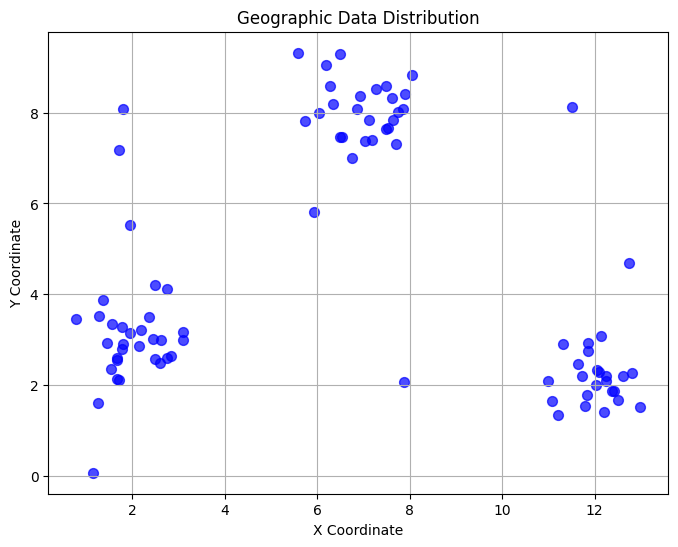

In [6]:
import matplotlib.pyplot as plt

# Create scatter plot using actual column names
plt.figure(figsize=(8,6))

plt.scatter(
    df["X_Coordinate"],
    df["Y_Coordinate"],
    color="blue",
    s=50,
    alpha=0.7
)

plt.title("Geographic Data Distribution")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(True)
plt.show()

In [8]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
print("Ishan Adhikari")
# Select geographic coordinates
X = df[["X_Coordinate", "Y_Coordinate"]]

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)

# Generate cluster labels
labels = dbscan.fit_predict(X)

# Store labels in dataframe
df["Cluster"] = labels

# Display cluster labels
print(df.head())

# Count clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Ishan Adhikari
  LocationID  X_Coordinate  Y_Coordinate  Cluster
0       L001          1.29          3.53        0
1       L002          2.59          2.48        0
2       L003         12.14          3.08        2
3       L004          7.64          7.84        1
4       L005         12.21          1.40        2
Number of clusters: 3
Number of noise points: 9


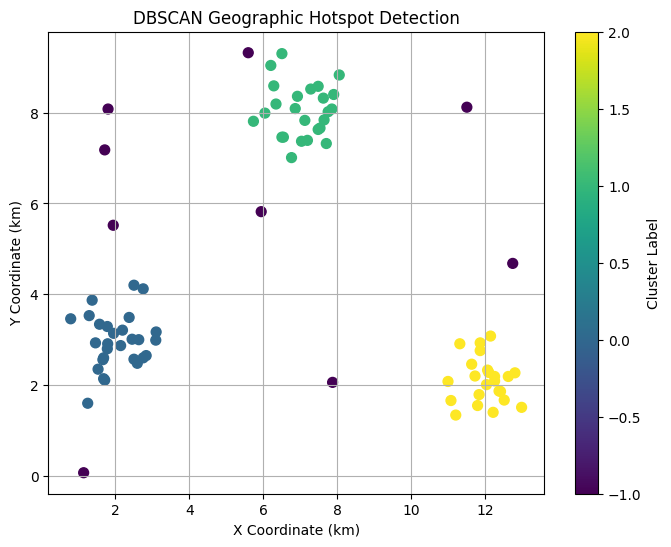

In [9]:
plt.figure(figsize=(8,6))

# Plot DBSCAN clusters
plt.scatter(
    X["X_Coordinate"],
    X["Y_Coordinate"],
    c=labels,
    cmap="viridis",
    s=50
)

plt.title("DBSCAN Geographic Hotspot Detection")
plt.xlabel("X Coordinate (km)")
plt.ylabel("Y Coordinate (km)")

plt.colorbar(label="Cluster Label")
plt.grid(True)

plt.show()

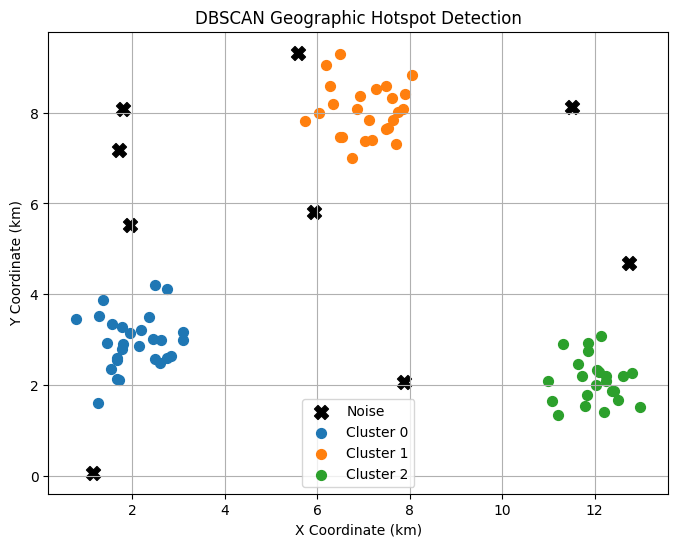

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Get unique cluster labels
unique_labels = np.unique(labels)

# Plot each cluster separately
for label in unique_labels:
    if label == -1:
        # Plot noise points with X marker
        plt.scatter(
            X[labels == label]["X_Coordinate"],
            X[labels == label]["Y_Coordinate"],
            color="black",
            marker="X",
            s=100,
            label="Noise"
        )
    else:
        # Plot clusters with different colors
        plt.scatter(
            X[labels == label]["X_Coordinate"],
            X[labels == label]["Y_Coordinate"],
            s=50,
            label=f"Cluster {label}"
        )

plt.title("DBSCAN Geographic Hotspot Detection")
plt.xlabel("X Coordinate (km)")
plt.ylabel("Y Coordinate (km)")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
from sklearn.cluster import DBSCAN
import pandas as pd
print("Ishan Adhikari")

# Select geographic coordinates
X = df[["X_Coordinate", "Y_Coordinate"]]

# Different DBSCAN parameter settings
parameters = [
    (0.5, 5),
    (0.8, 5),
    (1.0, 5),
    (0.8, 7)
]

results = []

for eps, min_samples in parameters:

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Count clusters excluding noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Count noise points
    n_noise = list(labels).count(-1)

    results.append([eps, min_samples, n_clusters, n_noise])

# Create comparison table
results_df = pd.DataFrame(
    results,
    columns=["eps", "min_samples", "Number of Clusters", "Noise Points"]
)

print(results_df)

Ishan Adhikari
   eps  min_samples  Number of Clusters  Noise Points
0  0.5            5                   3            27
1  0.8            5                   3             9
2  1.0            5                   3             8
3  0.8            7                   3             9


Ishan Adhikari


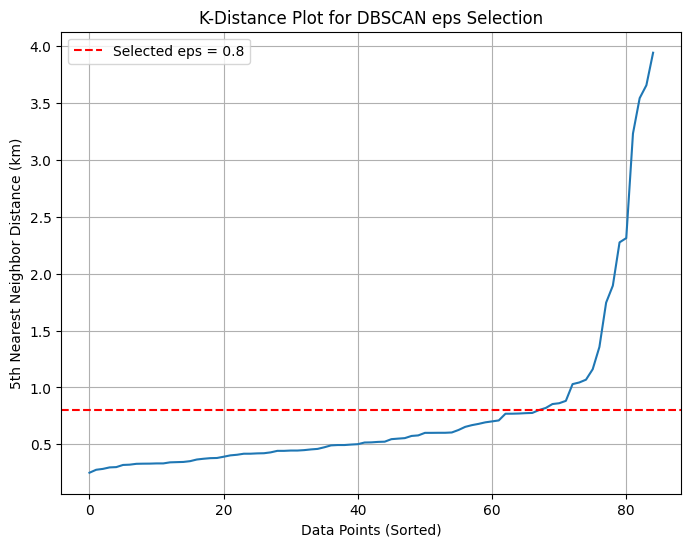

In [14]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
print("Ishan Adhikari")
# Select geographic coordinates
X = df[["X_Coordinate", "Y_Coordinate"]]

# Set k equal to min_samples
k = 5

# Calculate distances to the k nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

# Sort the distance to the kth nearest neighbor
k_distances = np.sort(distances[:, k-1])

# Plot K-distance graph
plt.figure(figsize=(8,6))

plt.plot(k_distances)

plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.xlabel("Data Points (Sorted)")
plt.ylabel("5th Nearest Neighbor Distance (km)")

# Mark chosen eps value
plt.axhline(y=0.8, color="red", linestyle="--", label="Selected eps = 0.8")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
import pandas as pd

# Add cluster labels to dataframe
df["Cluster"] = labels
print("Ishan Adhikari")
# Calculate cluster centers (excluding noise -1)
hotspot_centers = df[df["Cluster"] != -1].groupby("Cluster")[["X_Coordinate", "Y_Coordinate"]].mean()

# Count hotspots
number_of_hotspots = len(hotspot_centers)

# Count noise points
noise_points = (df["Cluster"] == -1).sum()

print("Number of hotspots:", number_of_hotspots)
print("Number of noise points:", noise_points)

print("\nHotspot Centers:")
print(hotspot_centers)

Ishan Adhikari
Number of hotspots: 3
Number of noise points: 9

Hotspot Centers:
         X_Coordinate  Y_Coordinate
Cluster                            
0            2.042143      2.963929
1            7.051600      8.043600
2           11.999130      2.105652
